# Data Augmentation

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import albumentations as A

In [4]:
# 1. Define las transformaciones de Albumentations
transform = A.Compose([
    A.Rotate(limit=180, p=0.5),          # Rotación aleatoria hasta 180 grados con probabilidad 0.5
    A.HorizontalFlip(p=0.5),            # Volteo horizontal con probabilidad 0.5
    A.VerticalFlip(p=0.5),              # Volteo vertical con probabilidad 0.5
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3), # Ajuste de brillo y contraste aleatorio
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.3), # Ajuste de tono, saturación y valor
    A.RandomCrop(width=200, height=200, p=0.3), # Recorte aleatorio a 200x200
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),   # Desenfoque Gaussiano
    A.RandomScale(scale_limit=0.1, p=0.3),      # Escalado aleatorio con un límite de 10%
])

In [5]:
# 2. Carga algunas imágenes de ejemplo
# Asegúrate de tener un directorio llamado 'images' con algunas imágenes dentro.
image_dir = '/Users/alejandrolloveras/Documents/ESTUDIO/UBA/Trabajo Final/Desarrollo/data/samples/Inference/M'
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
images = []
transformations_applied = {}  # Dictionary to store transformations for each image

for file in image_files:
    img_path = os.path.join(image_dir, file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convertir a formato RGB para matplotlib
    images.append(img)

    # Apply transformations and store the applied transformations
    transformed = transform(image=img)
    transformation_titles = [t.__class__.__name__ for t in transform.transforms]
    transformations_applied[file] = transformation_titles

if not images:
    print(f"No se encontraron imágenes en el directorio: {image_dir}. Por favor, agrega algunas imágenes.")
    exit()

# Print the transformations applied for each image
#for img_file, transformations in transformations_applied.items():
#    print(f"Image: {img_file}, Transformations: {', '.join(transformations)}")

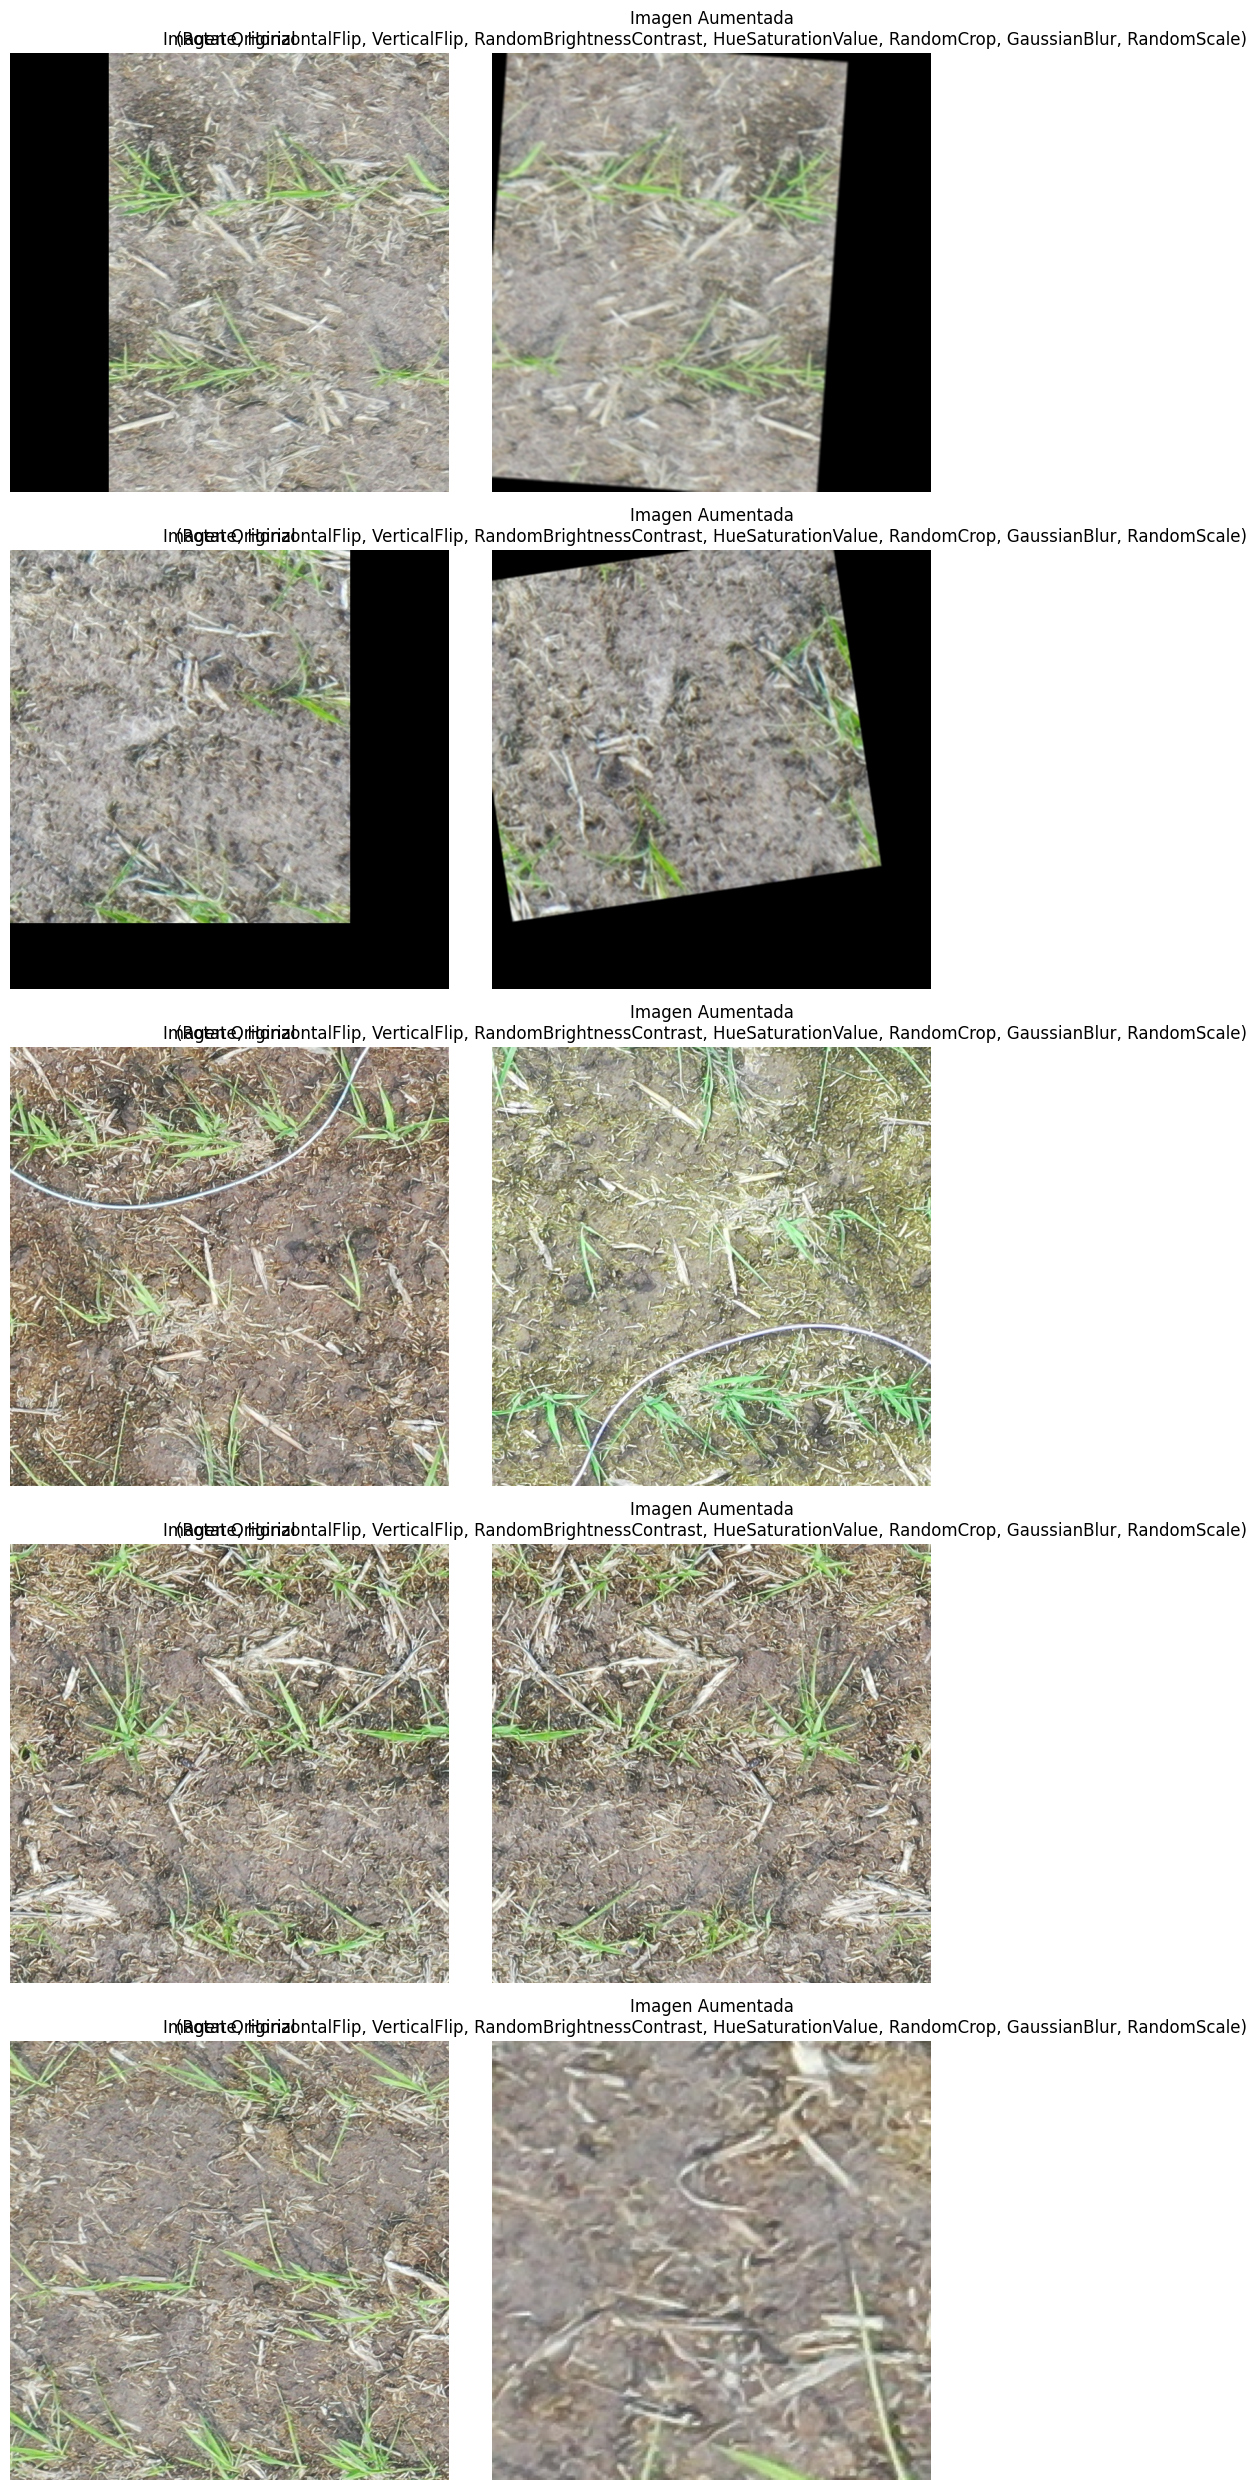

In [11]:
# 3. Aplica las transformaciones y visualiza los resultados con el título de la transformación aplicada
num_images_to_show = min(5, len(images))  # Mostrar hasta 5 imágenes
fig, axes = plt.subplots(num_images_to_show, 2, figsize=(10, 5 * num_images_to_show))

for i in range(num_images_to_show):
    original_image = images[i]
    img_file = image_files[i]  # Get the corresponding file name
    applied_transformations = transformations_applied.get(img_file, [])  # Get transformations for the image

    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title('Imagen Original')
    axes[i, 0].axis('off')

    transformed = transform(image=original_image)
    transformed_image = transformed['image']
    axes[i, 1].imshow(transformed_image)
    axes[i, 1].set_title(f'Imagen Aumentada\n({", ".join(applied_transformations)})')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

----

In [262]:
# 1. Customize the transformations
p = 0.9  # Probability of applying the transformation
transform = A.Compose([
#     A.Rotate(limit=180, p=p),          # Rotación aleatoria hasta 180 grados con probabilidad p
#     A.HorizontalFlip(p=p),            # Volteo horizontal con probabilidad p
#     A.VerticalFlip(p=p),              # Volteo vertical con probabilidad p
#     A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.5, p=p), # Ajuste de brillo y contraste aleatorio
#     A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=p), # Ajuste de tono, saturación y valor
     A.RandomCrop(width=400, height=400, p=p), # Recorte aleatorio a 400x400 con probabilidad p
     A.GaussianBlur(blur_limit=(20, 20), p=p),   # Desenfoque Gaussiano con probabilidad p
#     A.RandomScale(scale_limit=0.1, p=p),      # Escalado aleatorio con un límite de 10% y probabilidad p
])

Randomly selected image: tile03x01.503_222_54.640px.jpg
Transformations applied: Rotate, HorizontalFlip, VerticalFlip, RandomBrightnessContrast, HueSaturationValue, RandomCrop, GaussianBlur, RandomScale


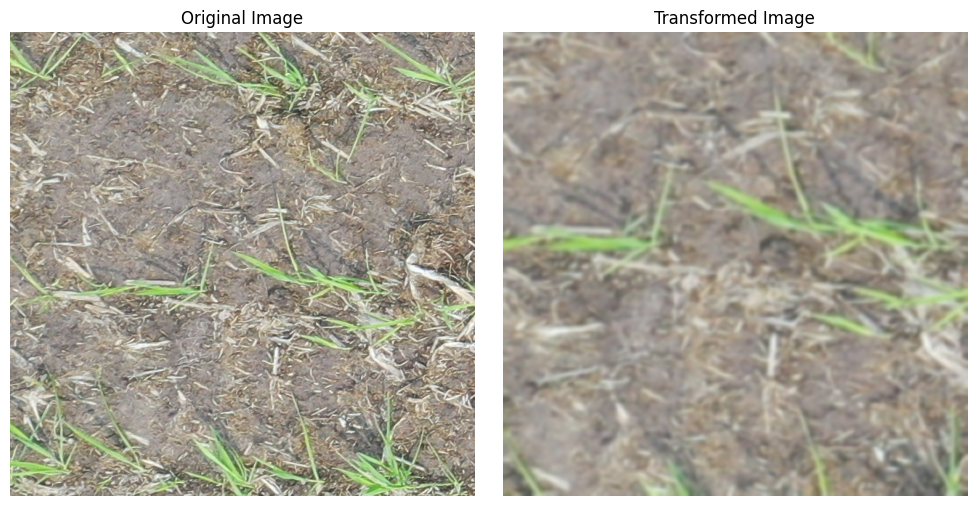

In [263]:
import random

# Select a random image
random_index = random.randint(0, len(image_files) - 1)
random_image = images[random_index]
random_image_file = image_files[random_index]

# Apply transformations
transformed = transform(image=random_image)
transformed_image = transformed['image']
applied_transformations = transformations_applied.get(random_image_file, [])

# Print the applied transformations
print(f"Randomly selected image: {random_image_file}")
print(f"Transformations applied: {', '.join(applied_transformations)}")

# Plot the original and transformed images
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(random_image)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(transformed_image)
#axes[1].set_title(f'Transformed Image\n({", ".join(applied_transformations)})')
axes[1].set_title(f'Transformed Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()